<img src="./src/LogoUTNNegro.png" align="right" width="150">

#### Teoría de los Circuitos 2

# Trabajo Semanal 4
#### Renzo Villani

### Consignas

A partir de la siguiente plantilla, sabiendo que en banda de paso la respuesta es *Chebyshev*:

<center><img src="./src/img1_TS4.png"></center>

- $f_0 = 22kHz; F_{s1}=17kHz; f_{s2}=36kHz$;
- $Q=5$ siendo $\omega1.\omega2=\omega_0² \space\space\space\space\space \omega2-\omega1 = \omega_0/Q$

1. Obtener la plantilla de atenuación normalizada en frecuencia.  Indicar los valores de $\alpha_{max}$ y de $\alpha_{min}$
2.  Obtener la función transferencia *normalizada* del prototipo pasa bajo que satisfaga el requerimiento del filtro pasa banda.
3.  Aplicar el núcleo de transformación *pasa banda* y obtener la transferencia. Factorizar convenientemente para expresar en *SOS*.
4.  Realizar la simulación numérica en python. Graficar la respuesta en frecuencia del filtro pasa banda total, y las de las SOS. 

**Bonus**

+10 💎 Simulación Circuital del filtro pasa banda implementado mediante secciones pasivas separadas por seguidores de tensión activos. 

+10 💎 Simulación Circuital del filtro *pasa banda* implementado mediante secciones pasivas separadas por seguidores de tensión activos.

+10 💎 Simulación Circuital del filtro pasa banda implementado mediante secciones pasivas separadas por seguidores de tensión activos.

$Z_{FDNR}=\frac{1}{s²D}$

### Punto 1

### Punto 2

In [46]:
# Importo las librerías para trabajar de acá en adelante.

# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
from scipy import signal as sig
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, analyze_sys, tf2sos_analog

from pytc2.general import a_equal_b_latex_s, print_latex

[-0.31322824+1.02192749j -0.31322824-1.02192749j -0.62645649+0.j        ]


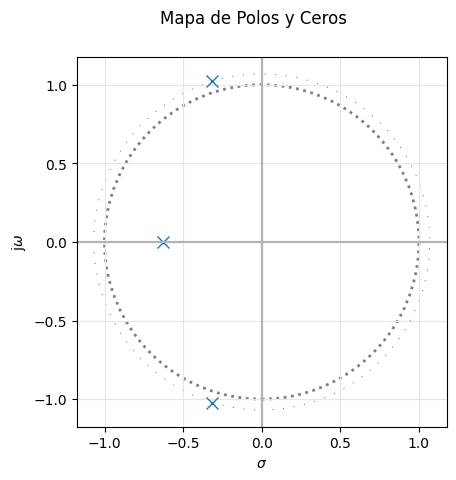

In [47]:
alfMax = 0.5

order = 3

# Para obtener la función transferencia del Cheby vía código directamente
# z,p,k = sig.cheb1ap(order, alfMax)
# num, den = sig.zpk2tf(z,p,k)

# Pero esta vez lo voy a hacer de forma manual

eps = np.sqrt( 10**(alfMax/10) - 1 )   # 0.34931140018894796

# Construyo |T|²
numsq = np.sqrt(1/16/ eps**2)
den = np.array([1, 0, 3/2, 0 , 9/16, 0 , -1/16/ eps**2])
Tsq = TransferFunction(numsq, den)   

# Contruyo la transferencia Cheby
num = np.sqrt(1/16/ eps**2)
roots = np.roots(den)
roots = roots[ np.real(roots) < 0 ]   # filtro los polos del semiplano derecho
den = np.poly(roots)
T = TransferFunction(num, den)

pzmap(T)
print(roots)

In [48]:
poles1 = np.array([
    -0.31322824+1.02192749j,
    -0.31322824-1.02192749j
])

poles2 = np.array([
    -0.62645649+0.j
])

zeros = []

num1, den1 = sig.zpk2tf(zeros, poles1, 1)
num2, den2 = sig.zpk2tf(zeros, poles2, 1)

# Fijo los numeradores para 0dB
num1 = den1[2]
num2 = den2[1]

# Contruyo las expresiones
s = sp.symbols("s");

num1_expr = num1
den1_expr = s**2 + s*den1[1] + den1[2]
num2_expr = num2
den2_expr = s + den2[1]

T1_expr = num1_expr / den1_expr
T2_expr = num2_expr / den2_expr

print_latex(a_equal_b_latex_s('T1(s)', T1_expr))
print_latex(a_equal_b_latex_s('T2(s)', T2_expr))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Punto 3

[-0.03450874+1.10691778j -0.03450874-1.10691778j -0.06264565+0.99803583j
 -0.06264565-0.99803583j -0.02813691+0.90253228j -0.02813691-0.90253228j]


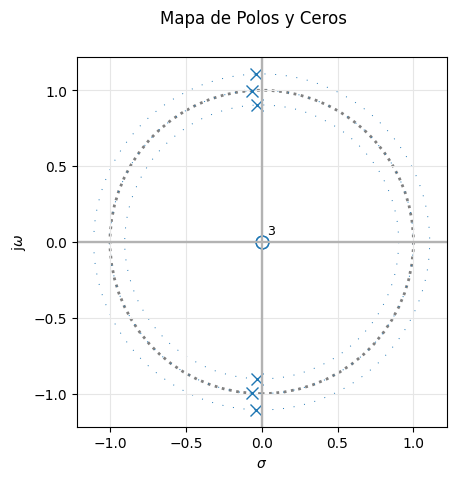

In [49]:
wo = 1
bw = 0.2

num, den = sig.lp2bp(num, den, wo, bw)
T = TransferFunction(num, den)

roots = np.roots(den)

pzmap(T)

print(roots)

In [57]:
poles1 = np.array([
    -0.03450874+1.10691778j,
    -0.03450874-1.10691778j
])

poles2 = np.array([
    -0.06264565+0.99803583j,
    -0.06264565-0.99803583j
])

poles3 = np.array([
    -0.02813691+0.90253228j,
    -0.02813691-0.90253228j
])

num1, den1 = sig.zpk2tf(zeros, poles1, 1)
num2, den2 = sig.zpk2tf(zeros, poles2, 1)
num3, den3 = sig.zpk2tf(zeros, poles3, 1)

# Fijo los numeradores para 0dB
num1 = den1[1]
num2 = den2[1]
num3 = den3[1]

T1 = TransferFunction(num1, den1)
T2 = TransferFunction(num2, den2)
T3 = TransferFunction(num3, den3)

# Contruyo las expresiones
s = sp.symbols("s");

num1_expr = s*den1[1]
den1_expr = s**2 + s*den1[1] + den1[2]
num2_expr = s*den2[1]
den2_expr = s**2 + s*den2[1] + den2[2]
num3_expr = s*den3[1]
den3_expr = s**2 + s*den3[1] + den3[2]

T1_expr = num1_expr / den1_expr
T2_expr = num2_expr / den2_expr
T3_expr = num3_expr / den3_expr

print_latex(a_equal_b_latex_s('T1(s)', T1_expr))
print_latex(a_equal_b_latex_s('T2(s)', T2_expr))
print_latex(a_equal_b_latex_s('T3(s)', T3_expr))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Punto 4

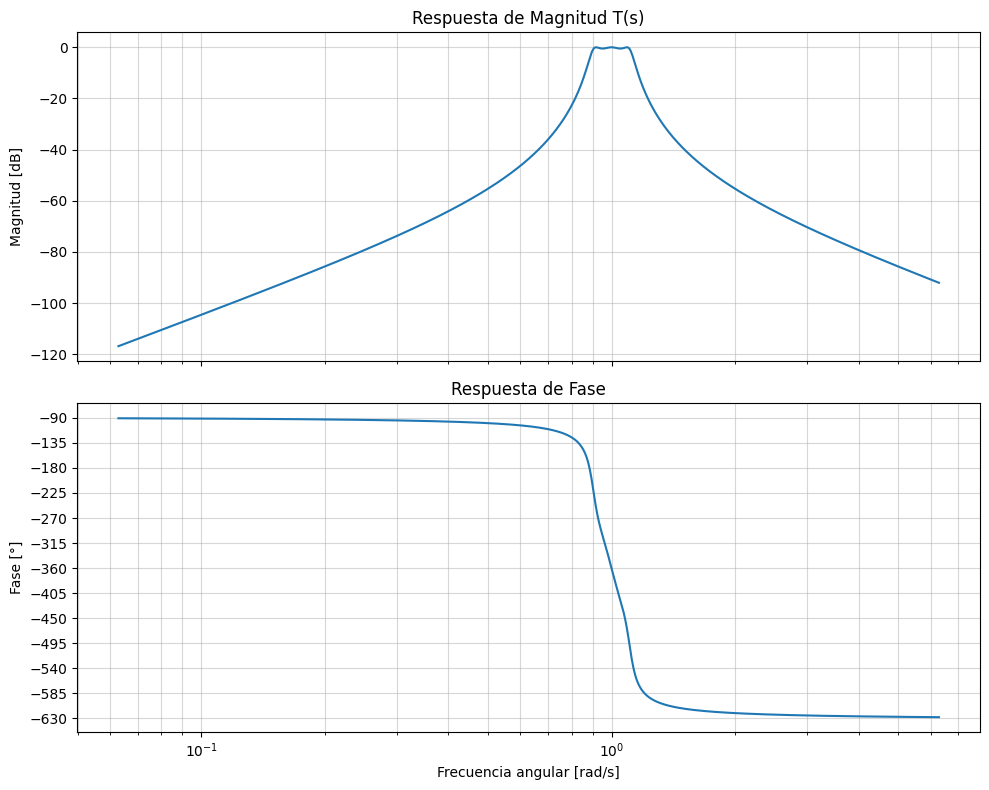

In [63]:
f = np.logspace(-2, 0, 1000)

w = 2*np.pi*f

w, mag, phase = sig.bode(T,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

attenuation_db = -mag

# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud T(s)')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-630, -89, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

ax_phase.set_xlabel('Frecuencia angular [rad/s]')


plt.tight_layout()
plt.show()

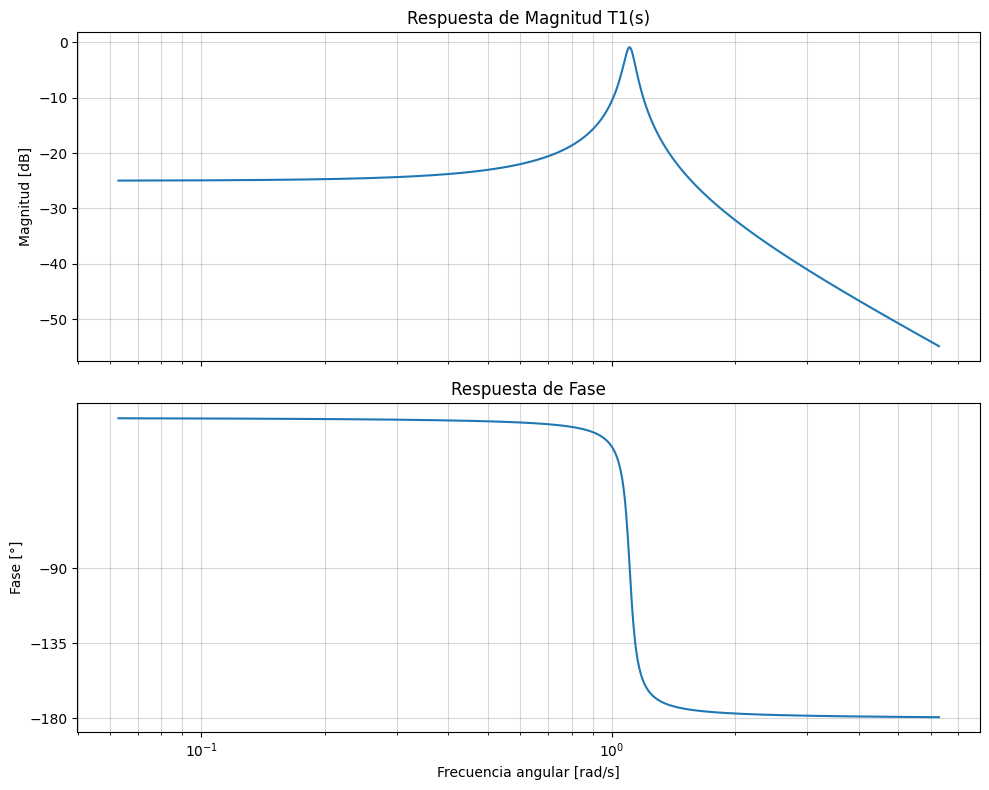

In [64]:
w, mag, phase = sig.bode(T1,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

attenuation_db = -mag

# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud T1(s)')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-630, -89, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

ax_phase.set_xlabel('Frecuencia angular [rad/s]')


plt.tight_layout()
plt.show()

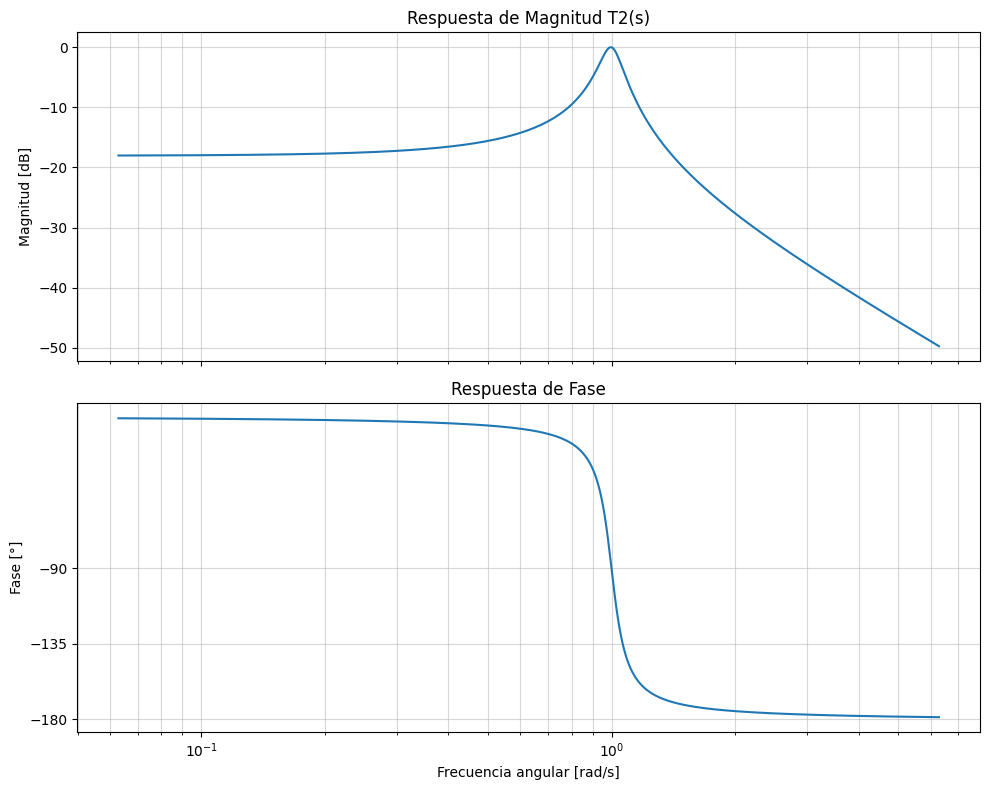

In [65]:
w, mag, phase = sig.bode(T2,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

attenuation_db = -mag

# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud T2(s)')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-630, -89, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

ax_phase.set_xlabel('Frecuencia angular [rad/s]')


plt.tight_layout()
plt.show()

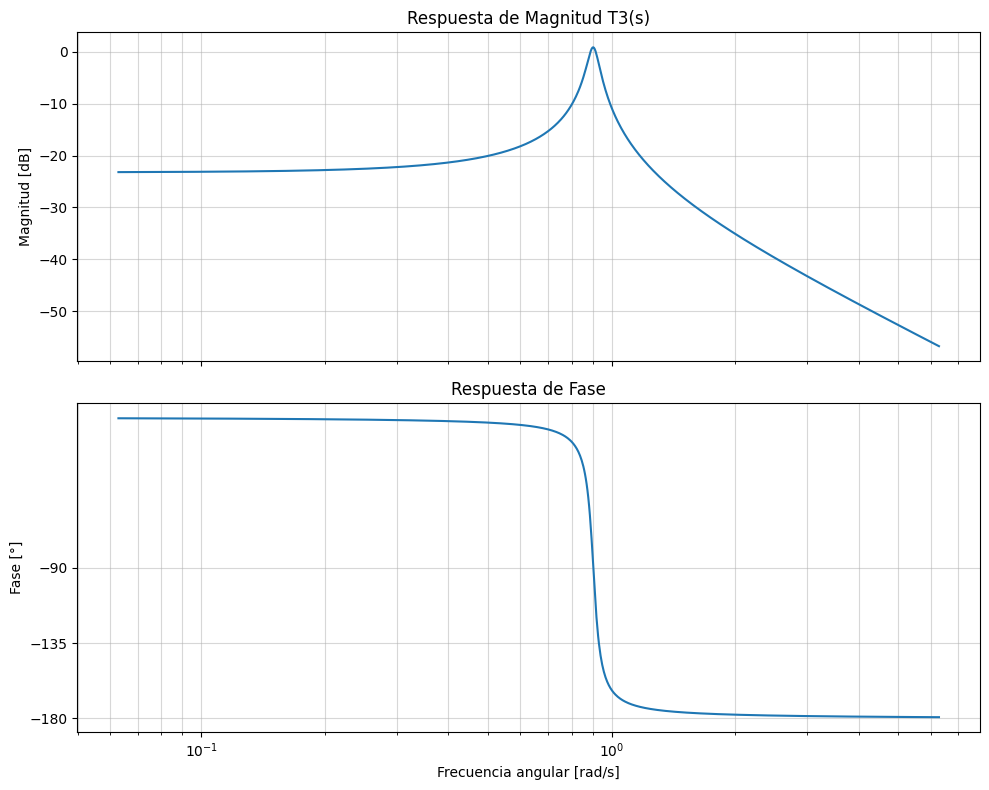

In [66]:
w, mag, phase = sig.bode(T3,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

attenuation_db = -mag

# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud T3(s)')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-630, -89, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

ax_phase.set_xlabel('Frecuencia angular [rad/s]')


plt.tight_layout()
plt.show()

### Bonus 1

### Bonus 2

### Bonus 3